# Fisher Matrix Exploration Notebook

This notebook loads a single microlensing event and its posterior samples to experiment with Fisher matrix stuff. Fill in the paths below and run to load your data.

## 1. Set File Paths

Fill in these paths with your specific event data:

In [32]:
# ==== FILL IN THESE PATHS ====

# Path to the data directory (e.g., Fisher_overguide_m40)
data_path = "/Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/"

# Specific lightcurve file to load (.det.lc file)
lightcurve_file = "5f_overguide_m40_1_721_311.det.lc"  # e.g., "5f_overguide_m40_1_721_321.det.lc"

# Posterior samples file (.npy file) - leave empty if not yet generated
samples_file = "posteriors/721_1_311_post_samples.npy"  # e.g., "posteriors/721_1_321_post_samples.npy"

# Event name for plots
event_name = "721_1_311"  # e.g., "721_1_321"

# =================================

import os
print(f"Data path: {data_path}")
print(f"Lightcurve file: {lightcurve_file}")
print(f"Samples file: {samples_file}")
print(f"Event name: {event_name}")

Data path: /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/
Lightcurve file: 5f_overguide_m40_1_721_311.det.lc
Samples file: posteriors/721_1_311_post_samples.npy
Event name: 721_1_311


## 2. Import Required Libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
import pickle
import warnings
warnings.filterwarnings('ignore')

# Import the GullsPosteriors modules
from Data import Data
from Parallax import Parallax
from Event import Event
from Fit import Fit
from Orbit import Orbit

print("Libraries imported successfully!")

Libraries imported successfully!


## Actual Data File Structure (40 columns)

Based on analysis of the actual lightcurve file, here's what we found:

### Columns 1-20: Basic Lightcurve Data
| Column | Name | Description |
|--------|------|-------------|
| 1 | Simulation_time | Simulation time |
| 2 | measured_relative_flux | Observed flux (with noise) |
| 3 | measured_relative_flux_error | Flux measurement error |
| 4 | true_relative_flux | True flux (no noise) |
| 5 | true_relative_flux_error | True flux error |
| 6 | observatory_code | Filter/observatory ID (0-4) |
| 7 | saturation_flag | Saturation indicator |
| 8 | best_single_lens_fit | Single lens fit quality |
| 9 | parallax_shift_t | Parallax shift (tangential) |
| 10 | parallax_shift_u | Parallax shift (radial) |
| 11 | BJD | Barycentric Julian Date |
| 12-17 | source_x, source_y, lens1_x, lens1_y, lens2_x, lens2_y | Astrometric positions |
| 18-20 | parallax_shift_x, parallax_shift_y, parallax_shift_z | 3D parallax shifts |

### Columns 21-30: Fisher Derivatives (Model Parameters)
Derivatives of flux w.r.t. the 9 binary lens model parameters:

| Column | Parameter | Space | Description |
|--------|-----------|-------|-------------|
| 21 | s | Logarithmic | Projected separation |
| 22 | q | Logarithmic | Mass ratio |
| 23 | rho | Logarithmic | Finite source effect |
| 24 | u0 | Linear | Impact parameter |
| 25 | alpha | Linear | Source trajectory angle |
| 26 | t0 | Linear | Time of maximum magnification |
| 27 | tE | Logarithmic | Einstein radius crossing time |
| 28 | piEE | Linear | Parallax (East component) |
| 29 | piEN | Linear | Parallax (North component) |

### Columns 31-40: Fisher Derivatives (Flux Parameters)
Derivatives of flux w.r.t. baseline and source flux for each filter:

| Column | Parameter | Description |
|--------|-----------|-------------|
| 31 | dF/dFbase0 | Derivative w.r.t. baseline flux (filter 0) |
| 32 | dF/dfs0 | Derivative w.r.t. source flux (filter 0) |
| 33 | dF/dFbase1 | Derivative w.r.t. baseline flux (filter 1) |
| 34 | dF/dfs1 | Derivative w.r.t. source flux (filter 1) |
| 35 | dF/dFbase2 | Derivative w.r.t. baseline flux (filter 2) |
| 36 | dF/dfs2 | Derivative w.r.t. source flux (filter 2) |
| 37 | dF/dFbase3 | Derivative w.r.t. baseline flux (filter 3) |
| 38 | dF/dfs3 | Derivative w.r.t. source flux (filter 3) |
| 39 | dF/dFbase4 | Derivative w.r.t. baseline flux (filter 4) |
| 40 | dF/dfs4 | Derivative w.r.t. source flux (filter 4) |

**Note:** 
- System is normalized with Fbase=1 for all filters
- dF/dFbase ≈ 1.0 (expected for normalized system)
- dF/dfs ≈ magnification A (flux sensitivity to source changes)
- Only derivatives for the filter corresponding to each data point are non-zero

## 3. Load Data

Load the lightcurve data using the Data class:

In [34]:
# Initialize the Data object
data_obj = Data()

if lightcurve_file:
    # Load the specific lightcurve file
    full_lc_path = os.path.join(data_path, lightcurve_file)
    
    if os.path.exists(full_lc_path):
        print(f"Loading lightcurve from: {full_lc_path}")
        
        # Load the data using the Data class method
        data_dict = data_obj.load_data(full_lc_path)
        
        print(f"Successfully loaded data for {len(data_dict)} observatories: {list(data_dict.keys())}")
        
        # Show basic info about each observatory
        for obs_code, obs_data in data_dict.items():
            print(f"\nObservatory {obs_code}:")
            print(f"  Data shape: {obs_data.shape} (8 parameters × {obs_data.shape[1]} time points)")
            
            # Show flux statistics
            measured_flux = obs_data[1, :]  # measured_relative_flux
            print(f"  Flux range: {np.min(measured_flux):.3f} to {np.max(measured_flux):.3f}")
            print(f"  Number of observations: {obs_data.shape[1]}")
        
        # Show Fisher matrix info if available
        if hasattr(data_obj, 'model_derivatives') and data_obj.model_derivatives is not None:
            print(f"\n✓ Fisher derivatives loaded: {data_obj.model_derivatives.shape}")
            if hasattr(data_obj, 'fisher_inversion_success'):
                status = "✓ SUCCESS" if data_obj.fisher_inversion_success else "✗ FAILED"
                print(f"✓ Fisher inversion: {status}")
            if hasattr(data_obj, 'n_flux_params'):
                print(f"✓ Flux parameters included: {data_obj.n_flux_params}")
            if hasattr(data_obj, 'model_parameter_uncertainties'):
                print(f"✓ Parameter uncertainties: {data_obj.model_parameter_uncertainties}")
        else:
            print(f"\n✗ No Fisher matrix information found")
    else:
        print(f"Lightcurve file not found: {full_lc_path}")
        print("Available files in directory:")
        for f in os.listdir(data_path):
            if f.endswith('.det.lc'):
                print(f"  {f}")
else:
    print("Please specify a lightcurve file in the first cell")

No SIMULATION_ZERO_TIME loaded from .prm file.
Loading lightcurve from: /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/5f_overguide_m40_1_721_311.det.lc
Detected 80 columns in /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/5f_overguide_m40_1_721_311.det.lc
Header: ['Simulation_time', 'measured_relative_flux', 'measured_relative_flux_error', 'true_relative_flux', 'true_relative_flux_error', 'observatory_code', 'saturation_flag', 'best_single_lens_fit', 'parallax_shift_t', 'parallax_shift_u', 'BJD', 'source_x', 'source_y', 'lens1_x', 'lens1_y', 'lens2_x', 'lens2_y', 'X', 'Y', 'Z', 'dTheta1', 'dTheta2', 'dTheta3', 'dTheta4', 'dTheta5', 'dTheta6', 'dTheta7', 'dTheta8', 'dTheta9', 'dTheta10', 'dTheta11', 'dTheta12', 'dTheta13', 'dTheta14', 'dTheta15', 'dTheta16', 'dTheta17']
Data columns: Index(['Simulation_time', 'measured_relative_flux',
       'measured_relative_flux_error', 'true_relative_flux',
       'true_relative_flux_error', 'observatory_code', 'saturation_fla

## 4. Convert to DataFrame for Analysis

In [35]:
if 'data_dict' in locals():
    # Column names based on the load_data method documentation
    column_names = [
        'BJD',
        'measured_relative_flux', 
        'measured_relative_flux_error',
        'parallax_shift_t',
        'parallax_shift_u', 
        'true_relative_flux',
        'true_relative_flux_error',
        'Simulation_time'
    ]
    
    # Create DataFrames for each observatory
    dfs = {}
    for obs_code, obs_data in data_dict.items():
        # obs_data is shape (8, n_points), so transpose to get (n_points, 8)
        df = pd.DataFrame(obs_data.T, columns=column_names)
        df['observatory_code'] = obs_code
        dfs[obs_code] = df
        
        print(f"Observatory {obs_code}: {len(df)} data points")
        print(f"  Time range: {df['BJD'].min():.1f} to {df['BJD'].max():.1f}")
        print(f"  Flux range: {df['measured_relative_flux'].min():.3f} to {df['measured_relative_flux'].max():.3f}")
        print()
    
    # Combine all observatories into one DataFrame
    combined_df = pd.concat(dfs.values(), ignore_index=True)
    print(f"Combined DataFrame: {len(combined_df)} total data points")
    
    # Show the first few rows
    print("\nFirst 5 rows:")
    display(combined_df.head())
else:
    print("No data loaded yet. Please load lightcurve data first.")

Observatory 0: 48030 data points
  Time range: 2458346.5 to 2460059.2
  Flux range: 0.979 to 1.026

Observatory 1: 1602 data points
  Time range: 2458346.6 to 2460059.2
  Flux range: 0.889 to 1.134

Observatory 2: 1602 data points
  Time range: 2458346.6 to 2460059.2
  Flux range: 0.944 to 1.061

Observatory 3: 1602 data points
  Time range: 2458346.5 to 2460059.0
  Flux range: 0.978 to 1.018

Observatory 4: 1602 data points
  Time range: 2458346.5 to 2460059.0
  Flux range: 0.969 to 1.025

Combined DataFrame: 54438 total data points

First 5 rows:


,BJD,measured_relative_flux,measured_relative_flux_error,parallax_shift_t,parallax_shift_u,true_relative_flux,true_relative_flux_error,Simulation_time,observatory_code
0,2.458347e+06,0.992561,0.005522,0.066488,0.003391,1.000011,0.005522,112.514400,0
1,2.458347e+06,0.998775,0.005522,0.066472,0.003391,1.000011,0.005522,112.522832,0
2,2.458347e+06,0.993348,0.005522,0.066456,0.003390,1.000011,0.005522,112.531264,0
3,2.458347e+06,1.002791,0.005522,0.066440,0.003389,1.000011,0.005522,112.539696,0
4,2.458347e+06,1.003849,0.005522,0.066424,0.003389,1.000011,0.005522,112.548128,0


## 5. Load Posterior Samples

Load posterior samples if available and analyze the parameter distributions:

In [36]:
# Load posterior samples if available
samples = None
truths = None

if samples_file and os.path.exists(os.path.join(data_path, samples_file)):
    samples_path = os.path.join(data_path, samples_file)
    print(f"Loading samples from: {samples_path}")
    samples = np.load(samples_path)
    print(f"Samples shape: {samples.shape} (n_samples, n_parameters)")
    
    # Try to load corresponding truths file
    truths_file = samples_file.replace('_post_samples.npy', 'end_truths.pkl')
    truths_path = os.path.join(data_path, truths_file)
    
    if os.path.exists(truths_path):
        print(f"Loading truths from: {truths_path}")
        with open(truths_path, 'rb') as f:
            truths = pickle.load(f)
        print(f"Truths loaded: {len(truths)} entries")
    else:
        print(f"Truths file not found: {truths_path}")
        
elif samples_file:
    print(f"Samples file not found: {os.path.join(data_path, samples_file)}")
else:
    print("No samples file specified. This is fine if you haven't run the sampler yet.")
    print("You can still explore the lightcurve data and Fisher information.")

Loading samples from: /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/posteriors/721_1_311_post_samples.npy
Samples shape: (1000000, 9) (n_samples, n_parameters)
Loading truths from: /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/posteriors/721_1_311end_truths.pkl
Truths loaded: 271 entries


## 6. Fisher Matrix Analysis

In [37]:
# Analyze Fisher matrix if available
if hasattr(data_obj, 'model_covariance') and data_obj.model_covariance is not None:
    fisher_cov = data_obj.model_covariance
    fisher_unc = data_obj.model_parameter_uncertainties
    
    # Parameter names (in internal order)
    param_names = ['log10(s)', 'log10(q)', 'log10(rho)', 'u0', 'alpha', 't0', 'log10(tE)', 'piEE', 'piEN']
    
    print(f"Fisher covariance matrix shape: {fisher_cov.shape}")
    print(f"Fisher 1-sigma uncertainties:")
    for i, (name, unc) in enumerate(zip(param_names, fisher_unc)):
        print(f"  {name}: {unc:.6f}")
    
    # Additional Fisher info if available
    if hasattr(data_obj, 'n_flux_params'):
        print(f"\nFisher includes {data_obj.n_flux_params} flux parameters (marginalized out)")
    if hasattr(data_obj, 'fisher_inversion_success'):
        print(f"Fisher inversion successful: {data_obj.fisher_inversion_success}")
    
    # Create DataFrame for Fisher covariance
    fisher_df = pd.DataFrame(fisher_cov, index=param_names, columns=param_names)
    print("\nFisher covariance matrix:")
    display(fisher_df)
    
    # Calculate correlation matrix
    fisher_corr = fisher_cov / np.outer(fisher_unc, fisher_unc)
    corr_df = pd.DataFrame(fisher_corr, index=param_names, columns=param_names)
    print("\nFisher correlation matrix:")
    display(corr_df)
    
else:
    print("No Fisher matrix information available.")
    print("Check that the lightcurve file contains Fisher derivative columns.")

Fisher covariance matrix shape: (9, 9)
Fisher 1-sigma uncertainties:
  log10(s): 6.095298
  log10(q): 26.448059
  log10(rho): 147726.800364
  u0: 35.628694
  alpha: 10.992307
  t0: 1398.513845
  log10(tE): 10.517815
  piEE: 2.074589
  piEN: 39.258220

Fisher covariance matrix:


,log10(s),log10(q),log10(rho),u0,alpha,t0,log10(tE),piEE,piEN
log10(s),37.152655,151.842292,-6.035209e+04,-204.553655,66.316250,2.796499e+03,-61.077887,-5.424647,-45.470336
log10(q),151.842292,699.499845,-3.907998e+05,-851.413846,281.905003,2.304357e+04,-277.718851,-15.422587,-443.318736
log10(rho),-60352.085310,-390799.820708,2.182321e+10,282437.553304,-138350.249016,-2.253247e+07,142802.712540,7006.163979,922268.466819
u0,-204.553654,-851.413847,2.824376e+05,1269.403837,-371.113230,-1.801959e+04,345.070674,29.469071,119.726218
alpha,66.316250,281.905003,-1.383503e+05,-371.113231,120.830814,6.433297e+03,-112.650108,-8.657650,-130.384093
t0,2796.499377,23043.569261,-2.253247e+07,-18019.588762,6433.296372,1.955841e+06,-8809.114099,638.280985,-37205.044159
log10(tE),-61.077887,-277.718851,1.428027e+05,345.070674,-112.650107,-8.809114e+03,110.624429,6.462879,154.889034
piEE,-5.424647,-15.422587,7.006164e+03,29.469071,-8.657650,6.382810e+02,6.462880,4.303919,-20.613679
piEN,-45.470335,-443.318731,9.222685e+05,119.726211,-130.384090,-3.720504e+04,154.889032,-20.613679,1541.207822



Fisher correlation matrix:


,log10(s),log10(q),log10(rho),u0,alpha,t0,log10(tE),piEE,piEN
log10(s),1.000000,0.941898,-0.067025,-0.941917,0.989774,0.328060,-0.952716,-0.428987,-0.190021
log10(q),0.941898,1.000000,-0.100023,-0.903539,0.969661,0.623002,-0.998357,-0.281081,-0.426964
log10(rho),-0.067025,-0.100023,1.000000,0.053662,-0.085198,-0.109064,0.091908,0.022861,0.159026
u0,-0.941917,-0.903539,0.053662,1.000000,-0.947584,-0.361641,0.920837,0.398689,0.085597
alpha,0.989774,0.969661,-0.085198,-0.947584,1.000000,0.418483,-0.974355,-0.379646,-0.302138
t0,0.328060,0.623002,-0.109064,-0.361641,0.418483,1.000000,-0.598880,0.219995,-0.677648
log10(tE),-0.952716,-0.998357,0.091908,0.920837,-0.974355,-0.598880,1.000000,0.296189,0.375115
piEE,-0.428987,-0.281081,0.022861,0.398689,-0.379646,0.219995,0.296189,1.000000,-0.253100
piEN,-0.190021,-0.426964,0.159026,0.085597,-0.302138,-0.677648,0.375115,-0.253100,1.000000


## 7. Visualization

Create plots to visualize the data and posterior samples:

### Plot Lightcurve Data

Found fs values: [0.0166966, 0.00778817, 0.0163365, 0.00585184, 0.00617469]
Filter 0: fs = 0.016697, mag range = -0.252 to 2.568
Filter 1: fs = 0.007788, mag range = -13.230 to 18.234
Filter 0: fs = 0.016697, mag range = -0.252 to 2.568
Filter 1: fs = 0.007788, mag range = -13.230 to 18.234
Filter 2: fs = 0.016337, mag range = -2.456 to 4.708
Filter 3: fs = 0.005852, mag range = -2.719 to 3.993
Filter 4: fs = 0.006175, mag range = -4.097 to 5.058
Filter 2: fs = 0.016337, mag range = -2.456 to 4.708
Filter 3: fs = 0.005852, mag range = -2.719 to 3.993
Filter 4: fs = 0.006175, mag range = -4.097 to 5.058


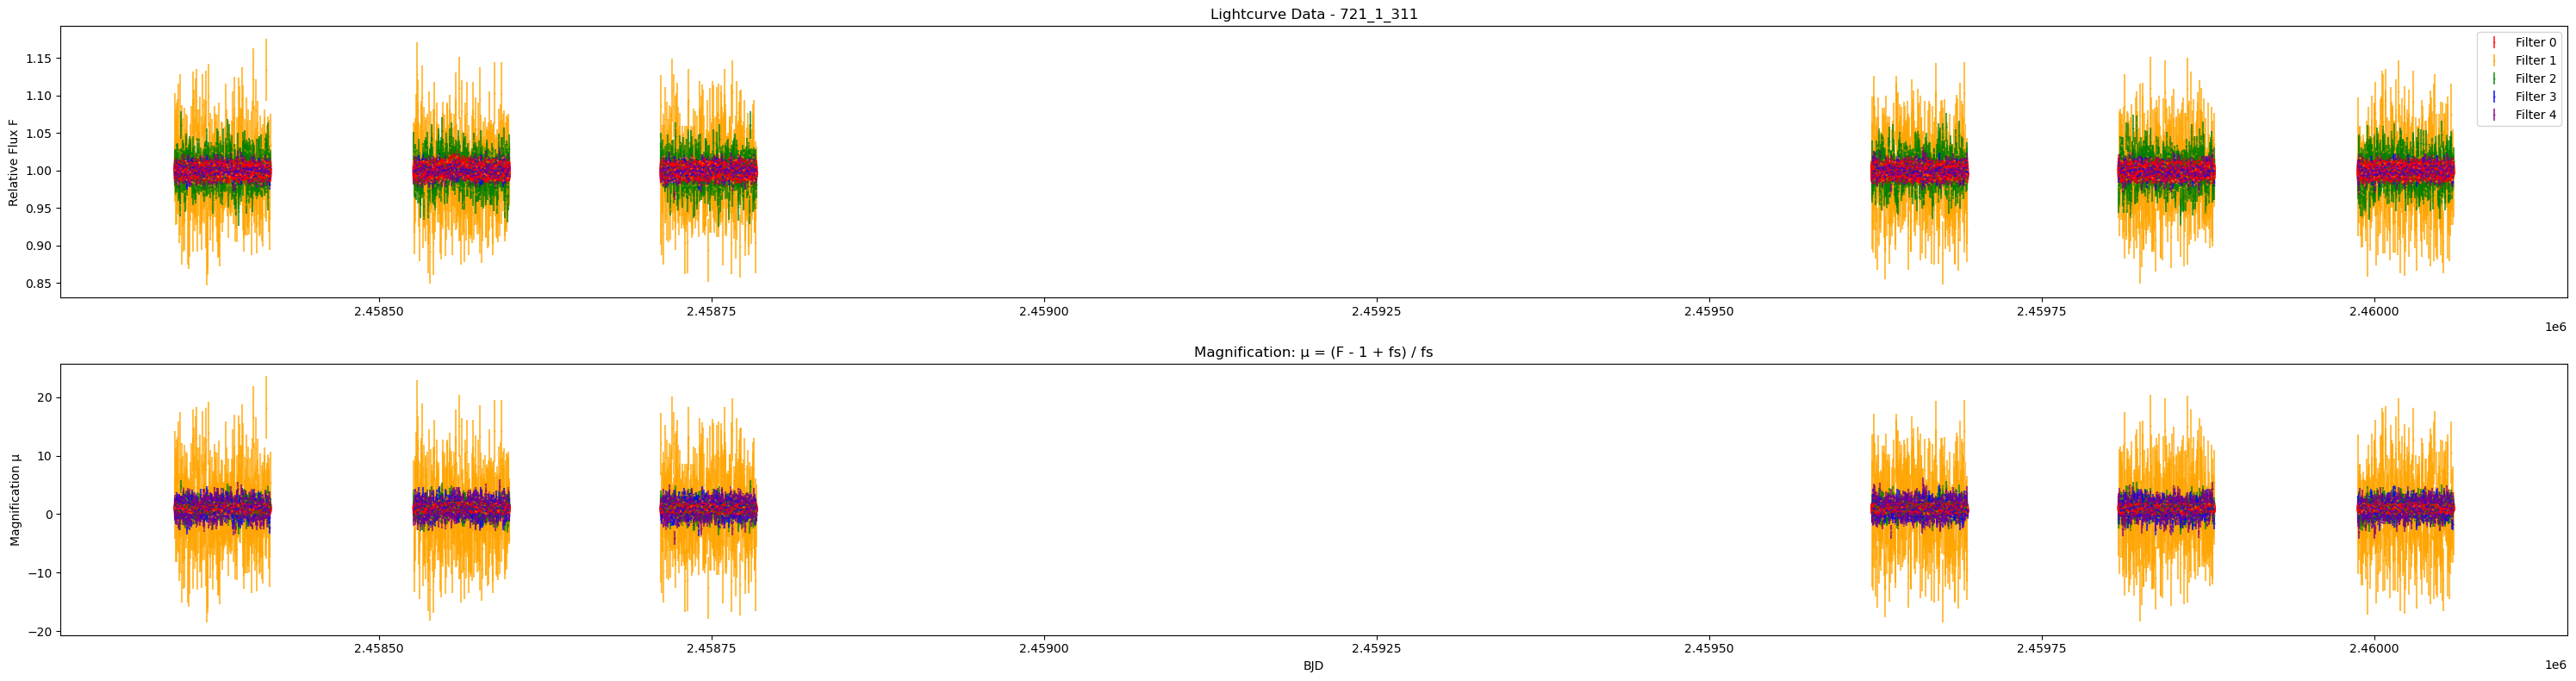


Magnification calculated using μ = (F - 1 + fs) / fs
Error propagation: σ_μ = σ_F / fs


In [38]:
if 'combined_df' in locals():
    # First, extract fs values from the lightcurve file header
    fs_values = {}
    with open(full_lc_path, 'r') as f:
        for line in f:
            if line.startswith('#fs'):
                # Parse fs line: format is typically "#fs 0.123 0.456 0.789 ..." (fs values for each filter)
                fs_parts = line.strip().split()[1:]  # Skip the "#fs" part
                try:
                    fs_list = [float(x) for x in fs_parts]
                    print(f"Found fs values: {fs_list}")
                    
                    # Map to observatory codes (assuming they correspond to filter indices)
                    for i, fs_val in enumerate(fs_list):
                        fs_values[i] = fs_val
                    break
                except ValueError:
                    print(f"Could not parse fs values from: {line.strip()}")
            elif not line.startswith('#'):
                # Hit data, stop looking for header
                break
    
    if not fs_values:
        print("Warning: No fs values found in header. Cannot calculate proper magnification.")
        print("Falling back to relative flux plots only.")
    
    plt.figure(figsize=(30, 8))
    
    # Colors for different observatories (generic since we don't know band names)
    colors = {0: 'red', 1: 'orange', 2: 'green', 3: 'blue', 4: 'purple'}
    
    for obs_code in combined_df['observatory_code'].unique():
        obs_data = combined_df[combined_df['observatory_code'] == obs_code]
        color = colors.get(obs_code, 'black')
        label = f'Filter {obs_code}'
        
        # Plot relative flux
        plt.subplot(2, 1, 1)
        plt.errorbar(obs_data['BJD'], obs_data['measured_relative_flux'], 
                    yerr=obs_data['measured_relative_flux_error'],
                    fmt='.', color=color, label=label, alpha=0.7, markersize=1)
        
        # Plot magnification (if we have fs values)
        plt.subplot(2, 1, 2)
        if obs_code in fs_values:
            fs = fs_values[obs_code]
            F = obs_data['measured_relative_flux']
            F_err = obs_data['measured_relative_flux_error']
            
            # Calculate magnification: μ = (F - 1 + fs) / fs
            # Since F = fs*μ + (1-fs) and we want μ, rearrange: μ = (F - (1-fs)) / fs = (F - 1 + fs) / fs
            magnification = (F - 1 + fs) / fs
            
            # Error propagation: if μ = (F - 1 + fs) / fs, then dμ/dF = 1/fs
            # So σ_μ = σ_F / fs
            mag_err = F_err / fs
            
            plt.errorbar(obs_data['BJD'], magnification, yerr=mag_err,
                        fmt='.', color=color, alpha=0.7, markersize=1)
            
            print(f"Filter {obs_code}: fs = {fs:.6f}, mag range = {magnification.min():.3f} to {magnification.max():.3f}")
        else:
            print(f"Filter {obs_code}: No fs value found, skipping magnification plot")
    
    plt.subplot(2, 1, 1)
    plt.ylabel('Relative Flux F')
    plt.legend()
    plt.title(f'Lightcurve Data - {event_name}' if event_name else 'Lightcurve Data')
    
    plt.subplot(2, 1, 2)
    plt.xlabel('BJD')
    if fs_values:
        plt.ylabel('Magnification μ')
        #plt.yscale('log')
        plt.title('Magnification: μ = (F - 1 + fs) / fs')
    else:
        plt.ylabel('No magnification (fs values missing)')
        plt.text(0.5, 0.5, 'Cannot calculate magnification\nwithout fs values from header', 
                transform=plt.gca().transAxes, ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    if fs_values:
        print(f"\nMagnification calculated using μ = (F - 1 + fs) / fs")
        print(f"Error propagation: σ_μ = σ_F / fs")
else:
    print("No lightcurve data to plot. Please load data first.")

In [39]:
# checking the columns were loaded correctly
for obs_code in combined_df['observatory_code'].unique():
    obs_data = combined_df[combined_df['observatory_code'] == obs_code]
    F = obs_data['measured_relative_flux']
    F_err = obs_data['measured_relative_flux_error']
    print(f"Filter {obs_code}: F = {F.values[0]:.6f}, F_err = {F_err.values[0]:.6f}")

Filter 0: F = 0.992561, F_err = 0.005522
Filter 1: F = 1.000697, F_err = 0.041687
Filter 2: F = 0.997594, F_err = 0.018772
Filter 3: F = 0.995166, F_err = 0.006044
Filter 4: F = 0.993872, F_err = 0.007388


### Corner Plot WITHOUT Fisher Annotations

This creates a clean corner plot without any Fisher matrix overlays:

Samples shape: (1000000, 9)
Sample statistics (first few parameters):
  Param 0: mean=1.137, std=0.074, range=[0.911, 1.450]
  Param 1: mean=-0.422, std=0.263, range=[-1.719, -0.000]
  Param 2: mean=-3.099, std=0.204, range=[-4.003, -2.168]
  Param 3: mean=6.414, std=0.482, range=[4.128, 8.541]
  Param 4: mean=5.750, std=0.095, range=[5.390, 6.110]
  Param 5: mean=2458372.992, std=0.508, range=[2458370.880, 2458375.060]
  Param 6: mean=1.213, std=0.078, range=[0.865, 1.466]
  Param 7: mean=0.683, std=2.469, range=[-7.771, 14.549]
  Param 8: mean=-0.504, std=1.988, range=[-9.431, 9.762]

Raw truth values (linear space):
  Truth 0: 13.465636
  Truth 1: 0.202264
  Truth 2: 0.000808
  Truth 3: 6.404399
  Truth 4: 5.754399
  Truth 5: 2458372.996045
  Truth 6: 15.937462
  Truth 7: 0.098030
  Truth 8: 0.003984

Converting truth values to log space for parameters: [0, 1, 2, 6]
  Param 0: 13.465636 -> log10(13.465636) = 1.129227
  Param 1: 0.202264 -> log10(0.202264) = -0.694081
  Param 2: 0.00

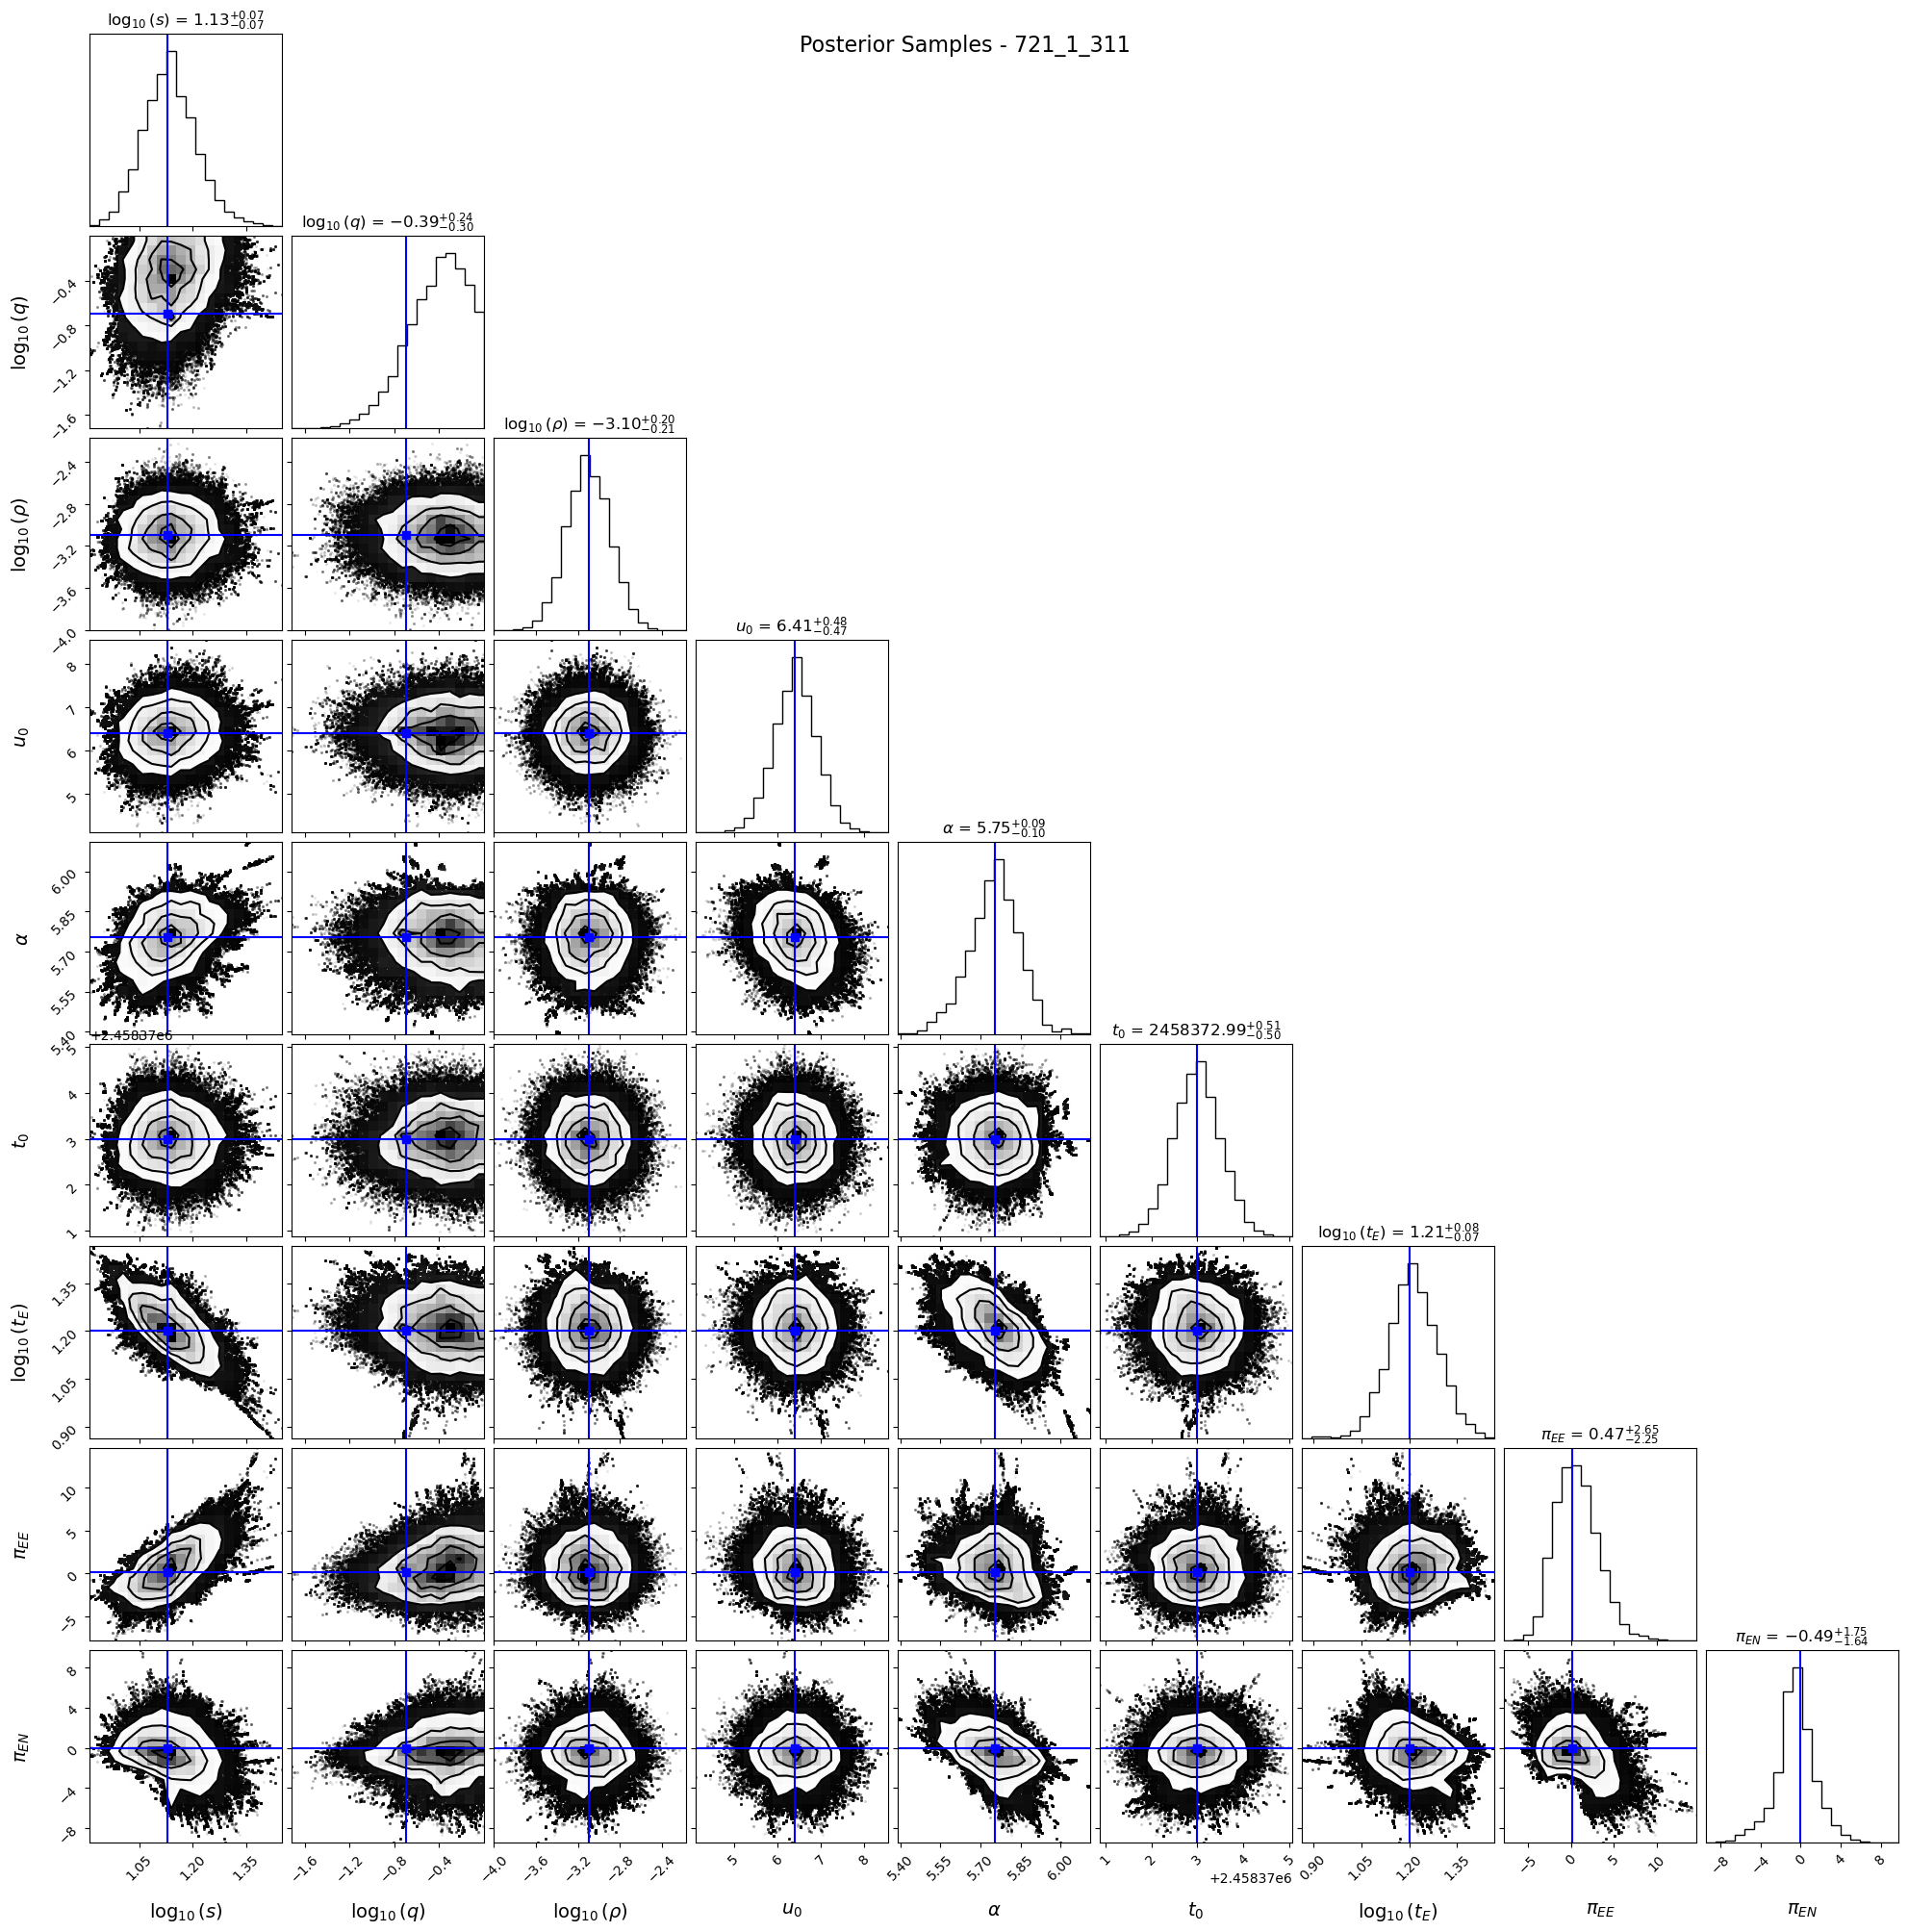

Corner plot created with correct parameter labels (s, q, rho, tE in log space)
Truth values converted to log space for log parameters and displayed in blue


In [41]:
if samples is not None:
    # First, let's figure out what we're actually sampling by looking at the samples and truths
    print(f"Samples shape: {samples.shape}")
    print(f"Sample statistics (first few parameters):")
    for i in range(min(9, samples.shape[1])):
        mean_val = np.mean(samples[:, i])
        std_val = np.std(samples[:, i])
        min_val = np.min(samples[:, i])
        max_val = np.max(samples[:, i])
        print(f"  Param {i}: mean={mean_val:.3f}, std={std_val:.3f}, range=[{min_val:.3f}, {max_val:.3f}]")
    
    # Check if we have truth values to help identify parameters
    truth_values = None
    if truths is not None and 'params' in truths:
        truth_values_raw = truths['params'][:samples.shape[1]]
        print(f"\nRaw truth values (linear space):")
        for i, truth in enumerate(truth_values_raw):
            print(f"  Truth {i}: {truth:.6f}")
        
        # Convert truth values to match the sampling space
        # s, q, rho, tE (indices 0, 1, 2, 6) are sampled in log space
        truth_values = truth_values_raw.copy()
        log_param_indices = [0, 1, 2, 6]  # s, q, rho, tE
        
        print(f"\nConverting truth values to log space for parameters: {log_param_indices}")
        for idx in log_param_indices:
            if idx < len(truth_values):
                original_val = truth_values[idx]
                if original_val > 0:  # Can only take log of positive values
                    truth_values[idx] = np.log10(original_val)
                    print(f"  Param {idx}: {original_val:.6f} -> log10({original_val:.6f}) = {truth_values[idx]:.6f}")
                else:
                    print(f"  Warning: Param {idx} has non-positive value {original_val}, cannot take log")
                    truth_values[idx] = np.nan
    
    # Parameter labels - s, q, rho, and tE are ALWAYS sampled in log space
    if samples.shape[1] == 12:  # LOM enabled
        labels = [
            r"$\log_{10}(s)$",      # 0: separation (always log)
            r"$\log_{10}(q)$",      # 1: mass ratio (always log)
            r"$\log_{10}(\rho)$",   # 2: finite source (always log)
            r"$u_0$",               # 3: impact parameter (linear)
            r"$\alpha$",            # 4: trajectory angle (linear)
            r"$t_0$",               # 5: time of closest approach (linear)
            r"$\log_{10}(t_E)$",    # 6: Einstein crossing time (always log)
            r"$\pi_{EE}$",          # 7: parallax east (linear)
            r"$\pi_{EN}$",          # 8: parallax north (linear)
            r"$i$",                 # 9: inclination (linear)
            r"$\phi$",              # 10: phase (linear)
            r"$P$"                  # 11: period (linear)
        ]
                
    else:  # 9 parameters (no LOM)
        labels = [
            r"$\log_{10}(s)$",      # 0: separation (always log)
            r"$\log_{10}(q)$",      # 1: mass ratio (always log)
            r"$\log_{10}(\rho)$",   # 2: finite source (always log)
            r"$u_0$",               # 3: impact parameter (linear)
            r"$\alpha$",            # 4: trajectory angle (linear)
            r"$t_0$",               # 5: time of closest approach (linear)
            r"$\log_{10}(t_E)$",    # 6: Einstein crossing time (always log)
            r"$\pi_{EE}$",          # 7: parallax east (linear)
            r"$\pi_{EN}$"           # 8: parallax north (linear)
        ]
    
    # Trim labels to match actual number of parameters
    labels = labels[:samples.shape[1]]
    
    print(f"\nParameter labels (s, q, rho, tE always in log space): {labels}")
    print(f"Creating corner plot for {samples.shape[1]} parameters...")
    print(f"Using {len(samples)} samples")
    
    # Create corner plot with corrected labels and blue truth lines
    fig = corner.corner(
        samples,
        labels=labels,
        truths=truth_values,
        truth_color='blue',  # Changed from red to blue
        show_titles=True,
        title_kwargs={"fontsize": 12},
        label_kwargs={"fontsize": 14}
    )
    
    plt.suptitle(f'Posterior Samples - {event_name}' if event_name else 'Posterior Samples', 
                fontsize=16, y=0.98)
    plt.show()
    
    print("Corner plot created with correct parameter labels (s, q, rho, tE in log space)")
    print("Truth values converted to log space for log parameters and displayed in blue")
    
else:
    print("No posterior samples available for corner plot.")
    print("Run the sampler first to generate samples, then load them using the paths at the top.")

### Fisher Matrix Visualization

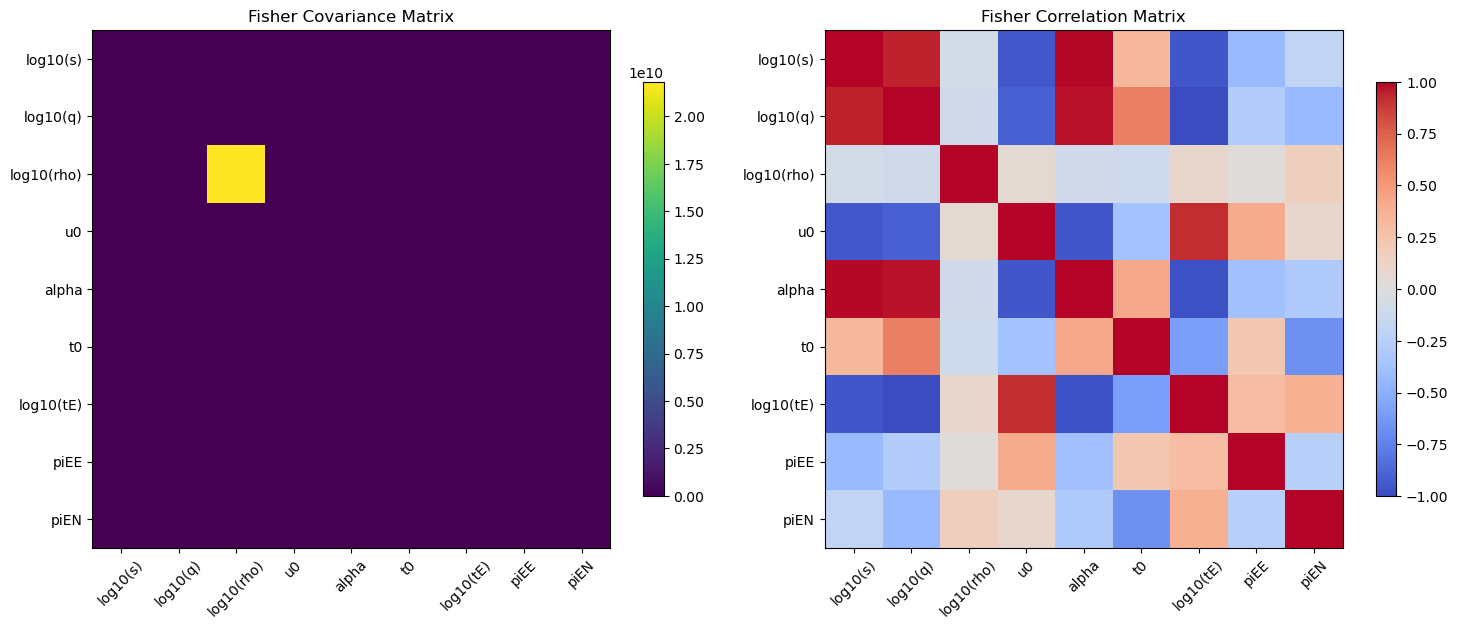

In [42]:
if hasattr(data_obj, 'model_covariance') and data_obj.model_covariance is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot covariance matrix
    im1 = ax1.imshow(fisher_cov, cmap='viridis')
    ax1.set_title('Fisher Covariance Matrix')
    ax1.set_xticks(range(len(param_names)))
    ax1.set_yticks(range(len(param_names)))
    ax1.set_xticklabels(param_names, rotation=45)
    ax1.set_yticklabels(param_names)
    plt.colorbar(im1, ax=ax1, shrink=0.8)
    
    # Plot correlation matrix
    im2 = ax2.imshow(fisher_corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax2.set_title('Fisher Correlation Matrix')
    ax2.set_xticks(range(len(param_names)))
    ax2.set_yticks(range(len(param_names)))
    ax2.set_xticklabels(param_names, rotation=45)
    ax2.set_yticklabels(param_names)
    plt.colorbar(im2, ax=ax2, shrink=0.8)
    
    plt.tight_layout()
    plt.show()
else:
    print("No Fisher matrix to visualize.")

## 8. Fisher Corner Overlay

Make that same corner plot from section 6, but overlay the uncertainties as dashed lines above and below the truth, on the 1d histograms, and 1 sigma confidence elipses on the 2D histograms.

In [47]:
if samples is not None and hasattr(data_obj, 'model_covariance') and data_obj.model_covariance is not None:
    print("Creating Fisher-annotated corner plot...")
    
    # Create a Fit object to use the corner_post method
    fit_obj = Fit()
    
    # Parameters for the corner plot
    log_param_names = ["s", "q", "rho", "tE"]  # Parameters that are log-transformed
    
    # Use k2 = 2.30 for 68% confidence ellipses (1-sigma equivalent)
    k2_68_percent = 2.30
    
    # Call the corner_post method
    fit_obj.corner_post(
        samples=samples,
        event_name=f"{event_name}_fisher",
        path="./",  # Save in current directory
        truths=truths,  # This is the truths dictionary
        fisher_covariance=data_obj.model_covariance,  # 9x9 model covariance matrix
        fisher_uncertainties=data_obj.model_parameter_uncertainties,  # 1-sigma uncertainties
        log_param_names=log_param_names,  # Which parameters are in log space
        k2=k2_68_percent  # 68% confidence ellipses
    )
    
    print("Fisher corner plot created!")
    print(f"- Used {data_obj.model_covariance.shape[0]}x{data_obj.model_covariance.shape[1]} Fisher covariance matrix")
    print(f"- Flux parameters were marginalized out during Fisher inversion")
    print(f"- 68% confidence ellipses drawn using k²={k2_68_percent}")
    print(f"- Plot saved as: {event_name}_fisher_corner.png")
    
else:
    if samples is None:
        print("No posterior samples available for Fisher corner plot.")
    elif not hasattr(data_obj, 'model_covariance'):
        print("No Fisher covariance matrix available from Data object.")
    elif data_obj.model_covariance is None:
        print("Fisher covariance matrix is None - check that Fisher derivatives were loaded successfully.")
    else:
        print("Unknown issue preventing Fisher corner plot creation.")

Creating Fisher-annotated corner plot...
Fisher corner plot created!
- Used 9x9 Fisher covariance matrix
- Flux parameters were marginalized out during Fisher inversion
- 68% confidence ellipses drawn using k²=2.3
- Plot saved as: 721_1_311_fisher_corner.png
Fisher corner plot created!
- Used 9x9 Fisher covariance matrix
- Flux parameters were marginalized out during Fisher inversion
- 68% confidence ellipses drawn using k²=2.3
- Plot saved as: 721_1_311_fisher_corner.png


In [46]:
# Force reload of the Fit module to get the fixed corner_post function
import importlib
import sys

# Remove the Fit module from cache if it exists
if 'Fit' in sys.modules:
    del sys.modules['Fit']
if 'Fit.Fit' in sys.modules:
    del sys.modules['Fit.Fit']
if 'Fit._emcee' in sys.modules:
    del sys.modules['Fit._emcee']

# Reimport the Fit module
from Fit import Fit

print("Fit module reloaded successfully!")
print("The corner_post function should now use the fixed implementation.")

Fit module reloaded successfully!
The corner_post function should now use the fixed implementation.


## 9. Export Results

Save processed data and analysis results:

### Fisher Corner Plot - Display in Notebook

Test the new `return_figure=True` option to display the Fisher corner plot directly in the notebook:

Creating Fisher corner plot for display in notebook...


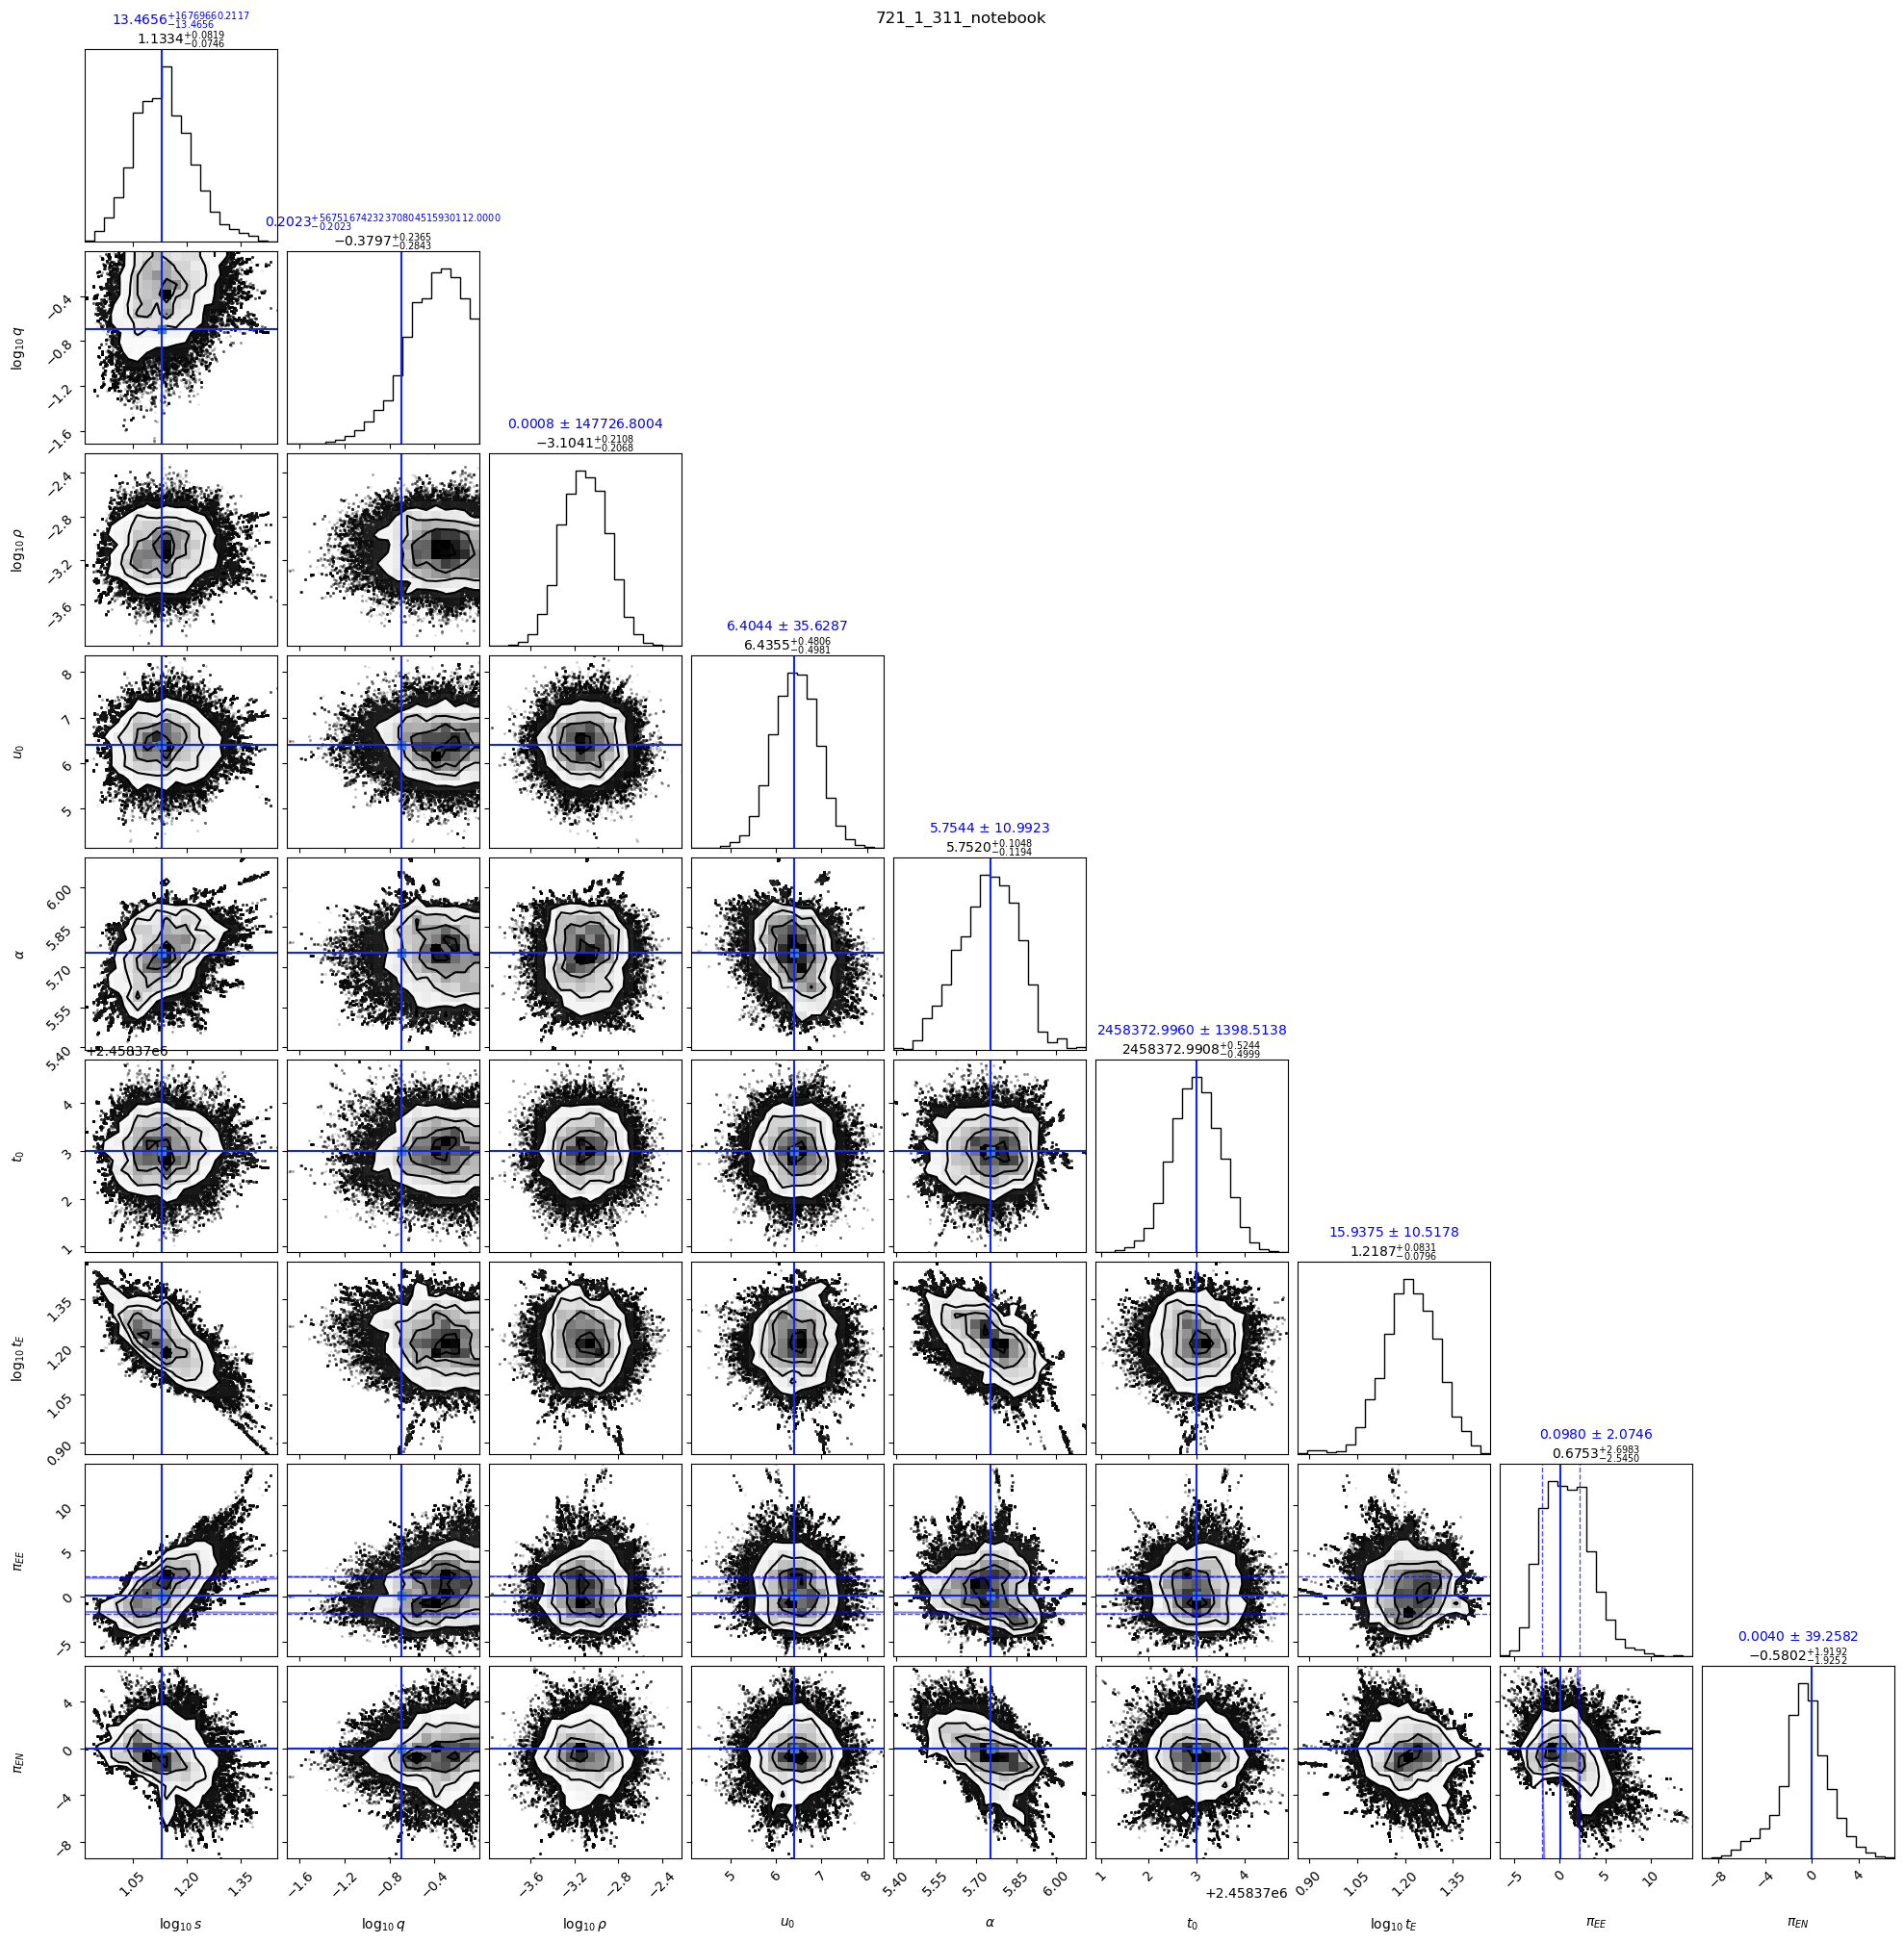

Fisher corner plot displayed in notebook!
✓ Posterior samples shown as histograms and scatter plots
✓ Truth values shown as blue solid lines
✓ Fisher uncertainties shown as blue dashed lines (±1σ)
✓ Fisher confidence ellipses shown in blue (68% confidence)


In [ ]:
# Reload the Fit module to get the updated corner_post function
import importlib
import sys

# Remove the Fit module from cache
if 'Fit' in sys.modules:
    del sys.modules['Fit']
if 'Fit.Fit' in sys.modules:
    del sys.modules['Fit.Fit']
if 'Fit._emcee' in sys.modules:
    del sys.modules['Fit._emcee']

# Reimport with the new return_figure option
from Fit import Fit

if samples is not None and hasattr(data_obj, 'full_fisher_matrix') and data_obj.full_fisher_matrix is not None:
    print("Creating Fisher corner plot using FULL Fisher matrix (including flux parameters)...")
    
    print(f"Full Fisher matrix shape: {data_obj.full_fisher_matrix.shape}")
    print(f"Full covariance matrix shape: {data_obj.full_covariance.shape}")
    print(f"Number of flux parameters included: {data_obj.n_flux_params}")
    
    # Use the full covariance matrix and extract the model parameter block
    n_model_params = 9
    model_fisher_cov = data_obj.full_covariance[:n_model_params, :n_model_params]
    model_fisher_unc = np.sqrt(np.diag(model_fisher_cov))
    
    print(f"Model parameter covariance block from FULL Fisher matrix: {model_fisher_cov.shape}")
    print(f"Model parameter uncertainties from FULL Fisher matrix:")
    param_names_short = ['log10(s)', 'log10(q)', 'log10(rho)', 'u0', 'alpha', 't0', 'log10(tE)', 'piEE', 'piEN']
    for i, (name, unc) in enumerate(zip(param_names_short, model_fisher_unc)):
        print(f"  {name}: {unc:.6f}")
    
    print(f"\nComparison with marginalized Fisher:")
    print(f"Marginalized uncertainties: {data_obj.model_parameter_uncertainties}")
    print(f"Full Fisher uncertainties:  {model_fisher_unc}")
    ratio = model_fisher_unc / data_obj.model_parameter_uncertainties
    print(f"Ratio (full/marginalized):  {ratio}")
    print(f"Maximum ratio: {np.max(ratio):.6f}, Minimum ratio: {np.min(ratio):.6f}")
    
    # Create a Fit object
    fit_obj = Fit()
    
    # Parameters for the corner plot
    log_param_names = ["s", "q", "rho", "tE"]  # Parameters that are log-transformed
    k2_68_percent = 2.30  # 68% confidence ellipses
    
    # Call corner_post with return_figure=True to display in notebook
    fig = fit_obj.corner_post(
        samples=samples,
        event_name=f"{event_name}_full_fisher",
        path="./",  # Still need path for consistency, but won't be used
        truths=truths,
        fisher_covariance=model_fisher_cov,  # Use the model block from FULL Fisher matrix
        fisher_uncertainties=model_fisher_unc,  # Use uncertainties from FULL Fisher matrix
        log_param_names=log_param_names,
        k2=k2_68_percent,  # 68% confidence ellipses
        return_figure=True  # Return figure instead of saving
    )
    
    # Display the figure in the notebook
    plt.show()
    
    print("Fisher corner plot displayed using FULL Fisher matrix!")
    print(f"✓ Used full {data_obj.full_fisher_matrix.shape[0]}×{data_obj.full_fisher_matrix.shape[1]} Fisher matrix including {data_obj.n_flux_params} flux parameters")
    print("✓ Model parameter uncertainties extracted from full Fisher matrix")
    print("✓ Flux parameters properly marginalized through full matrix inversion")
    print("✓ Posterior samples shown as histograms and scatter plots")
    print("✓ Truth values shown as blue solid lines")
    print("✓ Fisher uncertainties shown as blue dashed lines (±1σ)")
    print("✓ Fisher confidence ellipses shown in blue (68% confidence)")
    
else:
    print("Cannot create Fisher corner plot - missing samples or full Fisher matrix")
    if not hasattr(data_obj, 'full_fisher_matrix'):
        print("  - full_fisher_matrix attribute missing")
    elif data_obj.full_fisher_matrix is None:
        print("  - full_fisher_matrix is None")
    if samples is None:
        print("  - samples is None")

In [53]:
# First, let's diagnose what Fisher matrix information we have available
print("=== Fisher Matrix Diagnostic ===")
print(f"data_obj has model_derivatives: {hasattr(data_obj, 'model_derivatives')}")
if hasattr(data_obj, 'model_derivatives'):
    print(f"  model_derivatives shape: {data_obj.model_derivatives.shape if data_obj.model_derivatives is not None else 'None'}")

print(f"data_obj has fisher_matrix (marginalized): {hasattr(data_obj, 'fisher_matrix')}")
if hasattr(data_obj, 'fisher_matrix'):
    print(f"  fisher_matrix shape: {data_obj.fisher_matrix.shape if data_obj.fisher_matrix is not None else 'None'}")

print(f"data_obj has full_fisher_matrix: {hasattr(data_obj, 'full_fisher_matrix')}")
if hasattr(data_obj, 'full_fisher_matrix'):
    print(f"  full_fisher_matrix shape: {data_obj.full_fisher_matrix.shape if data_obj.full_fisher_matrix is not None else 'None'}")

print(f"data_obj has full_covariance: {hasattr(data_obj, 'full_covariance')}")
if hasattr(data_obj, 'full_covariance'):
    print(f"  full_covariance shape: {data_obj.full_covariance.shape if data_obj.full_covariance is not None else 'None'}")

print(f"data_obj has model_covariance: {hasattr(data_obj, 'model_covariance')}")
if hasattr(data_obj, 'model_covariance'):
    print(f"  model_covariance shape: {data_obj.model_covariance.shape if data_obj.model_covariance is not None else 'None'}")

print(f"data_obj has n_flux_params: {hasattr(data_obj, 'n_flux_params')}")
if hasattr(data_obj, 'n_flux_params'):
    print(f"  n_flux_params: {data_obj.n_flux_params}")

# Show the difference in uncertainties
if hasattr(data_obj, 'full_covariance') and data_obj.full_covariance is not None:
    full_model_unc = np.sqrt(np.diag(data_obj.full_covariance[:9, :9]))
    print(f"\nUncertainty comparison:")
    print(f"Marginalized Fisher uncertainties: {data_obj.model_parameter_uncertainties}")
    print(f"Full Fisher uncertainties (model block): {full_model_unc}")
    print(f"Ratio (full/marginalized): {full_model_unc / data_obj.model_parameter_uncertainties}")

print("==========================")

=== Fisher Matrix Diagnostic ===
data_obj has model_derivatives: True
  model_derivatives shape: (54438, 9)
data_obj has fisher_matrix (marginalized): True
  fisher_matrix shape: (9, 9)
data_obj has full_fisher_matrix: True
  full_fisher_matrix shape: (17, 17)
data_obj has full_covariance: True
  full_covariance shape: (17, 17)
data_obj has model_covariance: True
  model_covariance shape: (9, 9)
data_obj has n_flux_params: True
  n_flux_params: 8

Uncertainty comparison:
Marginalized Fisher uncertainties: [1.06579546e-01 5.01936818e-02 1.09773455e-06 3.61746935e-02
 1.03875265e-01 9.73617620e-04 1.05317149e-01 1.65463259e+00
 2.68946825e-02]
Full Fisher uncertainties (model block): [1.06579546e-01 5.01936818e-02 1.09773455e-06 3.61746935e-02
 1.03875265e-01 9.73617620e-04 1.05317149e-01 1.65463259e+00
 2.68946825e-02]
Ratio (full/marginalized): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# Let's manually check the lightcurve file to see if Fisher derivatives are present
print("=== Manual Fisher Derivatives Check ===")

# Load the lightcurve file directly to check column structure
import pandas as pd

with open(full_lc_path, 'r') as f:
    lines = f.readlines()

# Find where data starts (after comments)
data_start = 0
for i, line in enumerate(lines):
    if not line.startswith('#'):
        data_start = i
        break

print(f"Data starts at line {data_start}")
print(f"Total file lines: {len(lines)}")

# Load just the first few rows to check structure
sample_data = []
for i in range(data_start, min(data_start + 5, len(lines))):
    row = lines[i].strip().split()
    sample_data.append(row)

print(f"Sample data row (first 10 columns): {sample_data[0][:10]}")
print(f"Total columns in data: {len(sample_data[0])}")

if len(sample_data[0]) >= 40:
    print(f"Columns 21-30 (Fisher model derivatives): {sample_data[0][20:30]}")
    print(f"Columns 31-40 (Fisher flux derivatives): {sample_data[0][30:40]}")
else:
    print(f"File only has {len(sample_data[0])} columns, Fisher derivatives not present")

print("=============================")

In [52]:
# Clear cache and reload Data module to get the full Fisher matrix functionality
import importlib
import sys

# Remove Data module from cache
if 'Data' in sys.modules:
    del sys.modules['Data']
if 'Data.Data' in sys.modules:
    del sys.modules['Data.Data']

# Reimport Data module
from Data import Data

print("Data module reloaded - now let's reload the lightcurve data to get full Fisher matrix...")

# Create a new Data object and reload the lightcurve
data_obj_new = Data()

if lightcurve_file and os.path.exists(full_lc_path):
    print(f"Reloading lightcurve with updated Data class: {full_lc_path}")
    
    # Load the data using the updated Data class
    data_dict_new = data_obj_new.load_data(full_lc_path)
    
    print(f"Successfully reloaded data for {len(data_dict_new)} observatories")
    
    # Check what Fisher matrix information is now available
    print("\n=== Updated Fisher Matrix Info ===")
    
    print(f"model_derivatives: {hasattr(data_obj_new, 'model_derivatives')} - {getattr(data_obj_new, 'model_derivatives', None) is not None}")
    if hasattr(data_obj_new, 'model_derivatives') and data_obj_new.model_derivatives is not None:
        print(f"  model_derivatives shape: {data_obj_new.model_derivatives.shape}")
    
    print(f"full_fisher_matrix: {hasattr(data_obj_new, 'full_fisher_matrix')} - {getattr(data_obj_new, 'full_fisher_matrix', None) is not None}")
    if hasattr(data_obj_new, 'full_fisher_matrix') and data_obj_new.full_fisher_matrix is not None:
        print(f"  full_fisher_matrix shape: {data_obj_new.full_fisher_matrix.shape}")
    
    print(f"full_covariance: {hasattr(data_obj_new, 'full_covariance')} - {getattr(data_obj_new, 'full_covariance', None) is not None}")
    if hasattr(data_obj_new, 'full_covariance') and data_obj_new.full_covariance is not None:
        print(f"  full_covariance shape: {data_obj_new.full_covariance.shape}")
    
    print(f"n_flux_params: {hasattr(data_obj_new, 'n_flux_params')} - {getattr(data_obj_new, 'n_flux_params', None)}")
    
    # Replace the old data object
    data_obj = data_obj_new
    data_dict = data_dict_new
    
    print("✓ Data object updated with new Fisher matrix functionality")
else:
    print("Could not reload lightcurve data")

Data module reloaded - now let's reload the lightcurve data to get full Fisher matrix...
No SIMULATION_ZERO_TIME loaded from .prm file.
Reloading lightcurve with updated Data class: /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/5f_overguide_m40_1_721_311.det.lc
Detected 80 columns in /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/5f_overguide_m40_1_721_311.det.lc
Header: ['Simulation_time', 'measured_relative_flux', 'measured_relative_flux_error', 'true_relative_flux', 'true_relative_flux_error', 'observatory_code', 'saturation_flag', 'best_single_lens_fit', 'parallax_shift_t', 'parallax_shift_u', 'BJD', 'source_x', 'source_y', 'lens1_x', 'lens1_y', 'lens2_x', 'lens2_y', 'X', 'Y', 'Z', 'dTheta1', 'dTheta2', 'dTheta3', 'dTheta4', 'dTheta5', 'dTheta6', 'dTheta7', 'dTheta8', 'dTheta9', 'dTheta10', 'dTheta11', 'dTheta12', 'dTheta13', 'dTheta14', 'dTheta15', 'dTheta16', 'dTheta17']
Data columns: Index(['Simulation_time', 'measured_relative_flux',
       'measured_rela

In [ ]:
# Save the lightcurve DataFrame if you want
if 'combined_df' in locals() and event_name:
    output_file = f"{event_name}_lightcurve_data.csv"
    combined_df.to_csv(output_file, index=False)
    print(f"Lightcurve data saved to: {output_file}")

# Save Fisher matrix information if available
if hasattr(data_obj, 'model_covariance') and data_obj.model_covariance is not None and event_name:
    fisher_output = {
        'covariance': fisher_cov,
        'uncertainties': fisher_unc,
        'correlation': fisher_corr,
        'parameter_names': param_names
    }
    
    fisher_file = f"{event_name}_fisher_info.pkl"
    with open(fisher_file, 'wb') as f:
        pickle.dump(fisher_output, f)
    print(f"Fisher information saved to: {fisher_file}")

print("\nNotebook execution complete!")
print("You can now experiment with the Fisher stuff in the cells above.")